# 01 — EDA + Preprocessing cho OULAD (Random Forest)

**Mục tiêu:** khám phá, làm sạch, merge 7 bảng OULAD, tạo feature matrix `X` + target `y` để train Random Forest, xuất ra `data/processed/`.

**Quy ước granularity:** mỗi dòng = 1 *(student × module × presentation)*.

**Thứ tự clean:** clean per-table **trước khi join** (fix dtype, key, giá trị bất thường), rồi merge, rồi feature-level cleaning (impute, drop leakage) sau cùng.

**Về chuẩn hóa:** Random Forest là tree-based nên **KHÔNG cần scale/normalize** (StandardScaler, MinMaxScaler là thừa). Chỉ cần:
- Encode categorical (One-Hot / Ordinal)
- Impute missing values
- Xử lý leakage

## Section 1 — Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
np.random.seed(42)

def find_project_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'data' / 'raw').exists():
            return p
    raise RuntimeError('Cannot find project root containing data/raw')

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA_RAW     = {DATA_RAW}')
print(f'DATA_PROCESSED = {DATA_PROCESSED}')

PROJECT_ROOT = d:\Data Minning\oulad-pass-predictor
DATA_RAW     = d:\Data Minning\oulad-pass-predictor\data\raw
DATA_PROCESSED = d:\Data Minning\oulad-pass-predictor\data\processed


## Section 2 — Load 7 bảng OULAD

| Bảng | Vai trò | Key |
| --- | --- | --- |
| `studentInfo` | Demographics + nhãn `final_result` (base table) | (id_student, code_module, code_presentation) |
| `studentRegistration` | Ngày đăng ký / hủy | (id_student, code_module, code_presentation) |
| `studentAssessment` | Điểm từng assessment đã nộp | (id_student, id_assessment) |
| `assessments` | Metadata assessment (weight, date, type) | id_assessment |
| `studentVle` | Click log theo ngày, theo resource (file lớn) | (id_student, code_module, code_presentation, id_site, date) |
| `vle` | Metadata resource | id_site |
| `courses` | Độ dài presentation | (code_module, code_presentation) |

**Lưu ý dung lượng:** `studentVle.csv` có thể ~10M dòng. Dùng `dtype` gọn để tiết kiệm RAM.

In [2]:
student_info = pd.read_csv(DATA_RAW / 'studentInfo.csv')
student_registration = pd.read_csv(DATA_RAW / 'studentRegistration.csv')
student_assessment = pd.read_csv(DATA_RAW / 'studentAssessment.csv')
assessments = pd.read_csv(DATA_RAW / 'assessments.csv')
vle = pd.read_csv(DATA_RAW / 'vle.csv')
courses = pd.read_csv(DATA_RAW / 'courses.csv')

student_vle = pd.read_csv(
    DATA_RAW / 'studentVle.csv',
    dtype={
        'id_student': 'int32',
        'id_site': 'int32',
        'date': 'int16',
        'sum_click': 'int32',
    },
)

tables = {
    'studentInfo': student_info,
    'studentRegistration': student_registration,
    'studentAssessment': student_assessment,
    'assessments': assessments,
    'studentVle': student_vle,
    'vle': vle,
    'courses': courses,
}

for name, df in tables.items():
    print(f'{name:25s} shape = {df.shape}')

studentInfo               shape = (32593, 12)
studentRegistration       shape = (32593, 5)
studentAssessment         shape = (173912, 5)
assessments               shape = (206, 6)
studentVle                shape = (10655280, 6)
vle                       shape = (6364, 6)
courses                   shape = (22, 3)


## Section 3 — EDA per-table + clean trước khi join

Với mỗi bảng: kiểm tra shape, dtype, missing, duplicate trên key. Clean các vấn đề rõ ràng **trước khi join** để aggregate / merge không bị hỏng.

### 3.1 — `studentInfo` (base table)

In [3]:
print(student_info.dtypes)
print('\nMissing:')
print(student_info.isnull().sum())
student_info.head()

code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

Missing:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


Duplicate rows on key ['id_student', 'code_module', 'code_presentation']: 0

final_result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


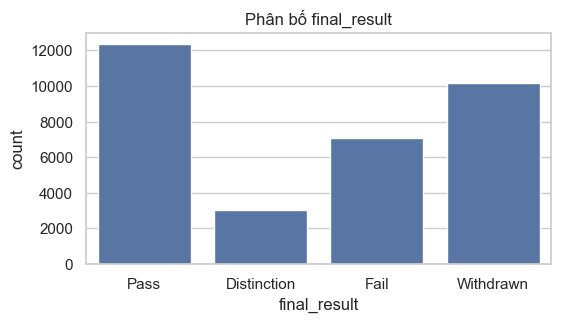

In [4]:
key_cols = ['id_student', 'code_module', 'code_presentation']
dup = student_info.duplicated(subset=key_cols).sum()
print(f'Duplicate rows on key {key_cols}: {dup}')

print('\nfinal_result distribution:')
print(student_info['final_result'].value_counts())

fig, ax = plt.subplots(figsize=(6, 3))
sns.countplot(data=student_info, x='final_result', order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], ax=ax)
ax.set_title('Phân bố final_result')
plt.show()

In [5]:
# Clean: ép kiểu category cho các cột phân loại, giữ imd_band với NaN thật (không khai báo)
student_info['gender'] = student_info['gender'].astype('category')
student_info['region'] = student_info['region'].astype('category')
student_info['disability'] = student_info['disability'].astype('category')
student_info['highest_education'] = student_info['highest_education'].astype('category')
student_info['age_band'] = student_info['age_band'].astype('category')
# imd_band có dạng '0-10%', '10-20', ... — giữ nguyên string, NaN là giá trị hợp lệ

print('imd_band unique values:', student_info['imd_band'].dropna().unique())

imd_band unique values: ['90-100%' '20-30%' '30-40%' '50-60%' '80-90%' '70-80%' '60-70%' '40-50%'
 '10-20' '0-10%']


### 3.2 — `studentRegistration`

In [6]:
print(student_registration.dtypes)
print('\nMissing:')
print(student_registration.isnull().sum())

# date_unregistration NaN = chưa hủy đăng ký (không phải lỗi dữ liệu)
dup_reg = student_registration.duplicated(subset=key_cols).sum()
print(f'\nDuplicate rows on key: {dup_reg}')
student_registration.head()

code_module             object
code_presentation       object
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

Missing:
code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

Duplicate rows on key: 0


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


### 3.3 — `studentAssessment` + `assessments`

In [7]:
print('studentAssessment dtypes:')
print(student_assessment.dtypes)
print('\nMissing:')
print(student_assessment.isnull().sum())
print(f'\nscore missing rate: {student_assessment["score"].isnull().mean():.2%}')
student_assessment.head()

studentAssessment dtypes:
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

Missing:
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

score missing rate: 0.10%


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [8]:
# Clean: ép score về numeric (phòng trường hợp có '?'), drop row không có score (không có tín hiệu)
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')
before = len(student_assessment)
student_assessment = student_assessment.dropna(subset=['score'])
print(f'Dropped {before - len(student_assessment)} rows with missing score')

print('\nassessments dtypes:')
print(assessments.dtypes)
print('\nassessment_type distribution:')
print(assessments['assessment_type'].value_counts())
# date NaN chỉ với exam cuối kỳ — để nguyên (impute sau nếu cần)

Dropped 173 rows with missing score

assessments dtypes:
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
dtype: object

assessment_type distribution:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64


### 3.4 — `studentVle`

In [9]:
print('studentVle dtypes:')
print(student_vle.dtypes)
print(f'\nshape = {student_vle.shape}')
print(f'sum_click >= 0: {(student_vle["sum_click"] >= 0).all()}')
print(f'date range: {student_vle["date"].min()} to {student_vle["date"].max()}')
student_vle.head()

studentVle dtypes:
code_module          object
code_presentation    object
id_student            int32
id_site               int32
date                  int16
sum_click             int32
dtype: object

shape = (10655280, 6)
sum_click >= 0: True
date range: -25 to 269


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


## Section 4 — Aggregate `studentVle` → click features

Group theo `(id_student, code_module, code_presentation)`. Giữ granularity sau aggregate trùng với master table.

In [10]:
click_agg = student_vle.groupby(key_cols).agg(
    total_clicks=('sum_click', 'sum'),
    num_active_days=('date', 'nunique'),
    max_clicks_day=('sum_click', 'max'),
    first_active_day=('date', 'min'),
    last_active_day=('date', 'max'),
    num_resources_accessed=('id_site', 'nunique'),
).reset_index()

click_agg['mean_clicks_per_day'] = click_agg['total_clicks'] / click_agg['num_active_days']

print(f'click_agg shape = {click_agg.shape}')
click_agg.head()

click_agg shape = (29228, 10)


,id_student,code_module,code_presentation,total_clicks,num_active_days,max_clicks_day,first_active_day,last_active_day,num_resources_accessed,mean_clicks_per_day
0,6516,AAA,2014J,2791,159,49,-23,269,84,17.553459
1,8462,DDD,2013J,646,56,16,-6,118,125,11.535714
2,8462,DDD,2014J,10,1,7,10,10,3,10.000000
3,11391,AAA,2013J,934,40,76,-5,253,55,23.350000
4,23629,BBB,2013B,161,16,13,-6,87,11,10.062500


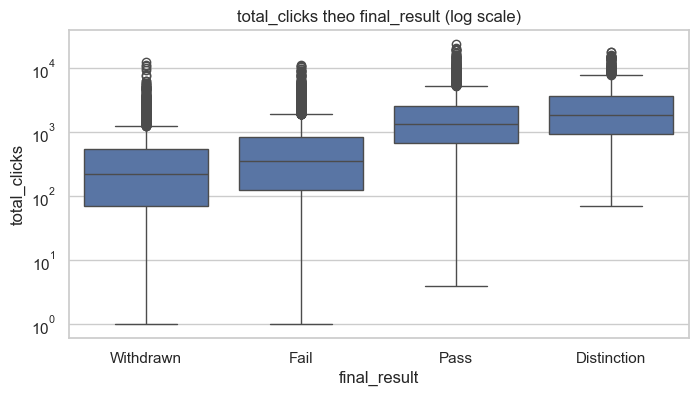

In [11]:
# Visualize: total_clicks theo final_result
tmp = click_agg.merge(student_info[key_cols + ['final_result']], on=key_cols, how='inner')
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=tmp, x='final_result', y='total_clicks',
            order=['Withdrawn', 'Fail', 'Pass', 'Distinction'], ax=ax)
ax.set_yscale('log')
ax.set_title('total_clicks theo final_result (log scale)')
plt.show()
del tmp

## Section 5 — Aggregate `studentAssessment` → assessment features

Join `studentAssessment` với `assessments` để lấy `weight`, `assessment_type`, `date` (deadline), rồi group về granularity master.

In [12]:
# Join với assessments để có code_module, code_presentation, weight, assessment_type, date (deadline)
sa = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'weight', 'date']],
    on='id_assessment',
    how='left',
    suffixes=('', '_assess'),
)
sa['is_late'] = (sa['date_submitted'] > sa['date']).astype(int)
sa['days_early'] = sa['date'] - sa['date_submitted']

def weighted_mean(group: pd.DataFrame) -> float:
    w = group['weight']
    if w.sum() == 0:
        return group['score'].mean()
    return (group['score'] * w).sum() / w.sum()

assess_agg = sa.groupby(key_cols).apply(
    lambda g: pd.Series({
        'mean_score': weighted_mean(g),
        'num_submissions': len(g),
        'num_late_submissions': g['is_late'].sum(),
        'mean_days_early': g['days_early'].mean(),
        'pct_tma_submitted': (g['assessment_type'] == 'TMA').mean(),
        'pct_cma_submitted': (g['assessment_type'] == 'CMA').mean(),
    }),
    include_groups=False,
).reset_index()

print(f'assess_agg shape = {assess_agg.shape}')
assess_agg.head()

assess_agg shape = (25820, 9)


,id_student,code_module,code_presentation,mean_score,num_submissions,num_late_submissions,mean_days_early,pct_tma_submitted,pct_cma_submitted
0,6516,AAA,2014J,63.50,5.0,0.0,2.600000,1.0,0.0
1,8462,DDD,2013J,87.25,3.0,1.0,0.333333,1.0,0.0
2,8462,DDD,2014J,86.00,4.0,0.0,59.500000,1.0,0.0
3,11391,AAA,2013J,82.40,5.0,0.0,1.800000,1.0,0.0
4,23629,BBB,2013B,66.76,4.0,3.0,-3.500000,0.5,0.5


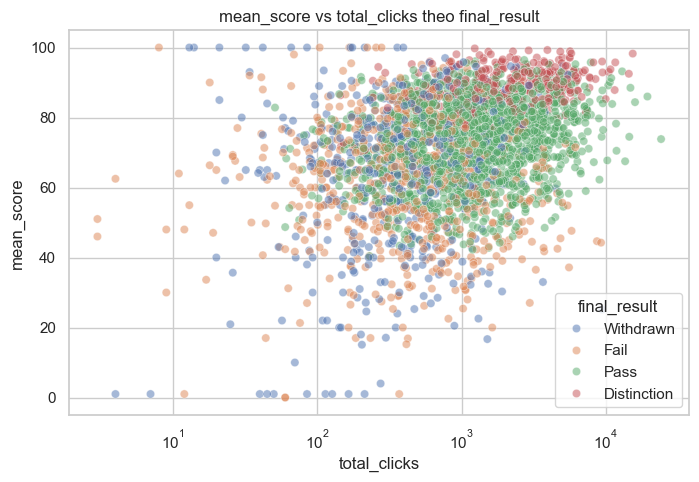

In [13]:
# Visualize: mean_score vs total_clicks tô theo final_result
tmp = (assess_agg[key_cols + ['mean_score']]
       .merge(click_agg[key_cols + ['total_clicks']], on=key_cols, how='inner')
       .merge(student_info[key_cols + ['final_result']], on=key_cols, how='inner'))
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=tmp.sample(min(3000, len(tmp)), random_state=42),
                x='total_clicks', y='mean_score', hue='final_result',
                hue_order=['Withdrawn', 'Fail', 'Pass', 'Distinction'], alpha=0.5, ax=ax)
ax.set_xscale('log')
ax.set_title('mean_score vs total_clicks theo final_result')
plt.show()
del tmp

## Section 6 — Merge về master table

Thứ tự: `studentInfo` (base) ← `studentRegistration` ← `click_agg` ← `assess_agg`. Tất cả đều LEFT JOIN để giữ nguyên số dòng base.

In [14]:
n_base = len(student_info)

df = student_info.merge(
    student_registration[key_cols + ['date_registration', 'date_unregistration']],
    on=key_cols, how='left',
)
df = df.merge(click_agg, on=key_cols, how='left')
df = df.merge(assess_agg, on=key_cols, how='left')

print(f'base = {n_base}, after merge = {len(df)} (phải bằng nhau)')
assert len(df) == n_base, 'Merge đã làm tăng/giảm số dòng!'

# Sinh viên không có click → fill 0
click_cols = ['total_clicks', 'num_active_days', 'max_clicks_day',
              'first_active_day', 'last_active_day', 'num_resources_accessed', 'mean_clicks_per_day']
df[click_cols] = df[click_cols].fillna(0)

# num_submissions NaN → 0; mean_score/days_early để NaN (imputer xử lý sau)
df['num_submissions'] = df['num_submissions'].fillna(0)
df['num_late_submissions'] = df['num_late_submissions'].fillna(0)
df['pct_tma_submitted'] = df['pct_tma_submitted'].fillna(0)
df['pct_cma_submitted'] = df['pct_cma_submitted'].fillna(0)

print('\nMissing rate sau merge:')
print(df.isnull().mean().sort_values(ascending=False).head(15))

base = 32593, after merge = 32593 (phải bằng nhau)

Missing rate sau merge:
date_unregistration     0.690977
mean_days_early         0.207836
mean_score              0.207805
imd_band                0.034087
date_registration       0.001381
region                  0.000000
highest_education       0.000000
id_student              0.000000
gender                  0.000000
code_presentation       0.000000
code_module             0.000000
disability              0.000000
studied_credits         0.000000
num_of_prev_attempts    0.000000
age_band                0.000000
dtype: float64


## Section 7 — Feature engineering sau join

Derive features từ các cột thô, drop các cột đã extract xong hoặc leakage.

In [15]:
# Số ngày đăng ký TRƯỚC ngày bắt đầu presentation (date = 0)
df['registered_days_before'] = -df['date_registration']

# LEAKAGE WARNING: date_unregistration có giá trị => sinh viên Withdrawn => leak 100% nếu
# ta coi Withdrawn = Fail. Vì vậy KHÔNG tạo feature has_unregistered, KHÔNG giữ date_unregistration.
df = df.drop(columns=['date_registration', 'date_unregistration'])

print('Columns sau feature engineering:')
print(df.columns.tolist())

Columns sau feature engineering:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_clicks', 'num_active_days', 'max_clicks_day', 'first_active_day', 'last_active_day', 'num_resources_accessed', 'mean_clicks_per_day', 'mean_score', 'num_submissions', 'num_late_submissions', 'mean_days_early', 'pct_tma_submitted', 'pct_cma_submitted', 'registered_days_before']


## Section 8 — Tạo target `y`

Convention: `Pass` ∪ `Distinction` = 1, `Fail` ∪ `Withdrawn` = 0. Coi Withdrawn như Fail để mô hình học được sớm cả nhóm bỏ học.

Tổng số mẫu: 32593
Tỉ lệ pass (y=1): 47.20%
Tỉ lệ fail (y=0): 52.80%


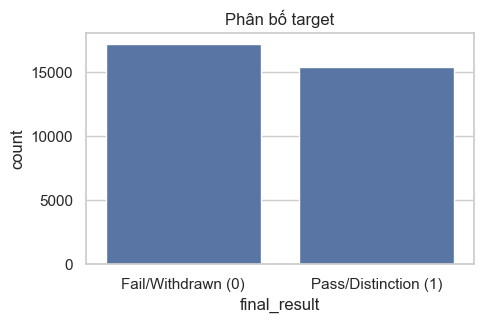

In [16]:
y = df['final_result'].isin(['Pass', 'Distinction']).astype(int)

print(f'Tổng số mẫu: {len(y)}')
print(f'Tỉ lệ pass (y=1): {y.mean():.2%}')
print(f'Tỉ lệ fail (y=0): {(1 - y.mean()):.2%}')

fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x=y, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fail/Withdrawn (0)', 'Pass/Distinction (1)'])
ax.set_title('Phân bố target')
plt.show()

## Section 9 — Chuẩn bị X và metadata cột

- Drop `final_result` (target) và `id_student` (định danh, không phải feature).
- Giữ `code_module`, `code_presentation` làm categorical feature (khác nhau giữa các khóa học → tín hiệu thật, không phải leakage).
- Phân loại 3 nhóm cột để build ColumnTransformer:
  - **numeric**: số đếm / tỉ lệ / thời gian
  - **categorical_ordinal**: có thứ tự tự nhiên (education, age, imd)
  - **categorical_nominal**: không có thứ tự

In [17]:
X = df.drop(columns=['final_result', 'id_student'])

numeric_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks', 'num_active_days', 'max_clicks_day',
    'first_active_day', 'last_active_day', 'num_resources_accessed', 'mean_clicks_per_day',
    'mean_score', 'num_submissions', 'num_late_submissions', 'mean_days_early',
    'pct_tma_submitted', 'pct_cma_submitted',
    'registered_days_before',
]
categorical_nominal = ['gender', 'region', 'disability', 'code_module', 'code_presentation']
categorical_ordinal = ['highest_education', 'age_band', 'imd_band']

# Thứ tự cho OrdinalEncoder
ordinal_categories = {
    'highest_education': [
        'No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
        'HE Qualification', 'Post Graduate Qualification',
    ],
    'age_band': ['0-35', '35-55', '55<='],
    'imd_band': [
        '0-10%', '10-20', '20-30%', '30-40%', '40-50%',
        '50-60%', '60-70%', '70-80%', '80-90%', '90-100%',
    ],
}

# Verify: tất cả cột đều được phân loại
all_listed = set(numeric_cols) | set(categorical_nominal) | set(categorical_ordinal)
missing = set(X.columns) - all_listed
extra = all_listed - set(X.columns)
assert not missing, f'Columns chưa phân loại: {missing}'
assert not extra, f'Columns liệt kê nhưng không có trong X: {extra}'

print(f'X shape = {X.shape}')
print(f'numeric ({len(numeric_cols)}): {numeric_cols}')
print(f'nominal ({len(categorical_nominal)}): {categorical_nominal}')
print(f'ordinal ({len(categorical_ordinal)}): {categorical_ordinal}')

X shape = (32593, 24)
numeric (16): ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'num_active_days', 'max_clicks_day', 'first_active_day', 'last_active_day', 'num_resources_accessed', 'mean_clicks_per_day', 'mean_score', 'num_submissions', 'num_late_submissions', 'mean_days_early', 'pct_tma_submitted', 'pct_cma_submitted', 'registered_days_before']
nominal (5): ['gender', 'region', 'disability', 'code_module', 'code_presentation']
ordinal (3): ['highest_education', 'age_band', 'imd_band']


## Section 10 — Demo ColumnTransformer Pipeline (chưa fit)

Mục đích: verify pipeline hoạt động đúng trên dữ liệu. **Không save pipeline đã fit** — `train.py` sau này sẽ fit trên train-split riêng để tránh leakage.

**Lưu ý RF:** không có `StandardScaler`, không có `MinMaxScaler`. Chỉ impute + encode.

In [18]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encode', OrdinalEncoder(
            categories=[ordinal_categories[c] + ['Unknown'] for c in categorical_ordinal],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )),
    ]), categorical_ordinal),
    ('nom', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_nominal),
])

# Fit thử trên 100 dòng đầu để verify shape output
sample = X.head(100).copy()
sample_out = preprocessor.fit_transform(sample)
print(f'Input shape:  {sample.shape}')
print(f'Output shape: {sample_out.shape}')
print(f'Output dtype: {sample_out.dtype}')
print('\nTrong train.py sau này: wrap preprocessor + RandomForestClassifier vào Pipeline, fit trên X_train.')

Input shape:  (100, 24)
Output shape: (100, 38)
Output dtype: float64

Trong train.py sau này: wrap preprocessor + RandomForestClassifier vào Pipeline, fit trên X_train.


In [19]:
!pip install pyarrow



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 11 — Save processed data

In [20]:
# Convert category dtype về object để parquet ghi được ổn định
X_out = X.copy()
for col in X_out.select_dtypes(include='category').columns:
    X_out[col] = X_out[col].astype(object)

X_out.to_parquet(DATA_PROCESSED / 'X.parquet', index=False)
y.to_frame('target').to_parquet(DATA_PROCESSED / 'y.parquet', index=False)

# Save sample để eyeball
X_out.head(100).to_csv(DATA_PROCESSED / 'X_sample.csv', index=False)

feature_metadata = {
    'numeric_cols': numeric_cols,
    'categorical_nominal': categorical_nominal,
    'categorical_ordinal': categorical_ordinal,
    'ordinal_categories': ordinal_categories,
    'target_rule': 'y=1 if final_result in {Pass, Distinction} else 0 (Withdrawn treated as Fail)',
    'n_samples': int(len(X_out)),
    'n_features': int(X_out.shape[1]),
    'pass_rate': float(y.mean()),
}
with open(DATA_PROCESSED / 'feature_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(feature_metadata, f, indent=2, ensure_ascii=False)

print('Đã ghi:')
for p in ['X.parquet', 'y.parquet', 'X_sample.csv', 'feature_metadata.json']:
    full = DATA_PROCESSED / p
    print(f'  {full} ({full.stat().st_size / 1024:.1f} KB)')

Đã ghi:
  d:\Data Minning\oulad-pass-predictor\data\processed\X.parquet (767.1 KB)
  d:\Data Minning\oulad-pass-predictor\data\processed\y.parquet (5.4 KB)
  d:\Data Minning\oulad-pass-predictor\data\processed\X_sample.csv (15.1 KB)
  d:\Data Minning\oulad-pass-predictor\data\processed\feature_metadata.json (1.3 KB)


## Section 12 — Summary & next steps

### Kết quả
- Merge 7 bảng OULAD → master table 1 dòng/(student × module × presentation)
- Tạo feature matrix raw (chưa encode) + target 0/1
- Xuất `X.parquet`, `y.parquet`, `feature_metadata.json` vào [data/processed/](../data/processed/)

### Feature list mới so với `StudentFeatures` schema gốc

| Nguồn | Schema cũ (9 fields) | Schema cần mở rộng |
| --- | --- | --- |
| studentInfo | gender, region, highest_education, imd_band, age_band, num_of_prev_attempts, studied_credits, disability | (giữ nguyên) + `code_module`, `code_presentation` |
| studentVle | sum_click | `total_clicks`, `num_active_days`, `max_clicks_day`, `first_active_day`, `last_active_day`, `num_resources_accessed`, `mean_clicks_per_day` |
| studentAssessment | — | `mean_score`, `num_submissions`, `num_late_submissions`, `mean_days_early`, `pct_tma_submitted`, `pct_cma_submitted` |
| studentRegistration | — | `registered_days_before` |

### Lưu ý về chuẩn hóa cho Random Forest
- **KHÔNG scale** numeric (RF là tree-based, không nhạy với scale)
- **Encode categorical**: OrdinalEncoder cho có thứ tự, OneHotEncoder cho nominal
- **Impute missing**: median (numeric), `'Unknown'` (categorical)
- **Leakage đã loại**: `date_unregistration` (leak Withdrawn → Fail)

### Next steps (ngoài scope notebook)
1. Cập nhật [backend/app/schemas/student.py](../backend/app/schemas/student.py) thêm các feature mới (hoặc tách 2 schema: `StudentDemographics` + `StudentBehavior`)
2. Port logic section 2–9 vào [backend/app/ml/preprocessing.py](../backend/app/ml/preprocessing.py) cho `load_raw()` và `build_features()`
3. Build full Pipeline (preprocessor + RandomForestClassifier) trong [backend/app/ml/train.py](../backend/app/ml/train.py), save nguyên pipeline qua `joblib.dump`
4. Update [backend/app/ml/predict.py](../backend/app/ml/predict.py) để pipeline auto-transform dict input → predict
5. Nhớ `_load_model.cache_clear()` sau mỗi lần retrain (xem [CLAUDE.md](../CLAUDE.md) — stale cache gotcha)